# Apuntes SQL: Diseño Fisico, creando Bases de datos, entidades, atributos y relaciones

Como ya vimos con anterioridad a la hora de realizar una BBDD hay que seguir unas fases definidas, siendo estas las siguientes:

* Analisis
* Diseño y moldeamiento
    * * Diseño Conceptual
    * * Diseño Logico
    * * **Diseño Fisico**
* Implementacion
* Uso y gestion de BBDD

En esta unidad nos vamos a centrar en el **diseño fisico** que es la materializacion de los diseños logicos realizados con el modelo relacional en un sistema gestor de Bases de datos

> A  estas alturas, ya tenemos que haber realizado:
> > El diseño conceptual o entidad - relacion
> > El modelo relacional y la normalizacion

**En esencia es la transposicion mediante consultas de SQL del modelo relacional**

## 1.0 Obtencion del modelo relacional

> Para desarrollar esta explicacion vamos a hacer uso de un grafo relacional ya creado

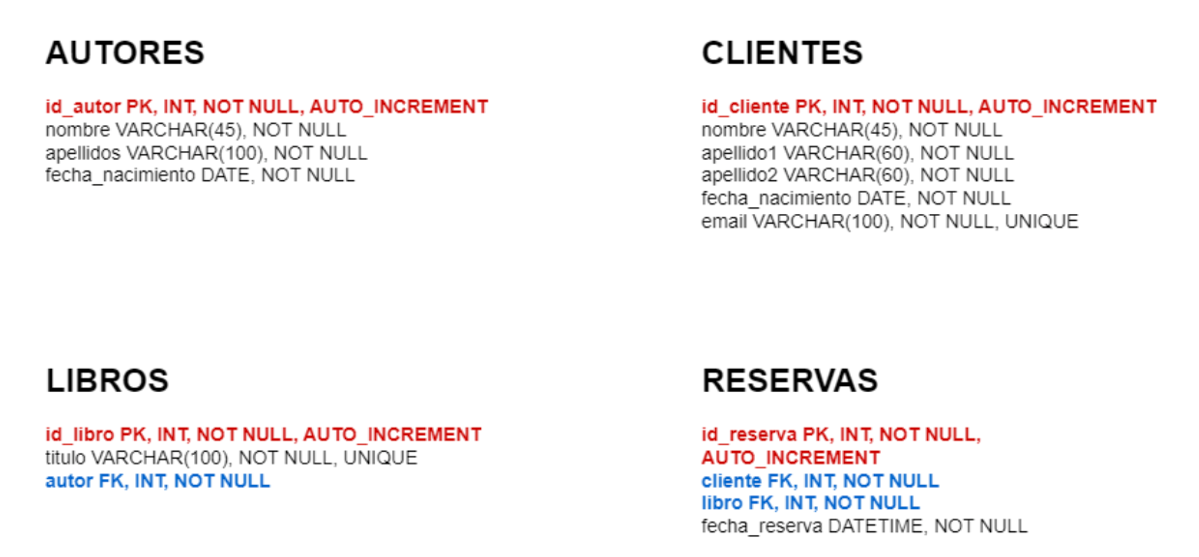

**A PARTIR DE ESTA INFORMACION SE PUEDE REALIZAR UNA BBDD, antes no**

## 2.0 Crear la BBDD

El primer comando a utilizar sera un DDL, el comando `CREATE`

En este caso sera necesario utilizarlo para crear la BBDD asi:

`CREATE DATABASE`

Sin embargo **ASI SE CREARIA CON INFO INCOMPLETA**

Para ello habra que indicar adicionalmente las siguientes sentencias:

- `IF NOT EXISTS nombreBBD` nos permitira **NO CREAR BBDD DUPLICADAS E IGNORE ERRORES DE EJECUCION DEL SCRIPT**
- `CHARACTER SET`  nos permitira **DEFINIR QUE CONJUNTO DE CARACTERES QUEREMOS UTILIZAR EN LA BBDD**
> **RECOMENDABLE UTILIZAR:** `utf8mb4`
- `COLLATE` indica la **COLACION PARA HACER USO DE CARACTERES ESPECIALES**
> **PARA USAR EN ESPAÑOL:** `utf8mb4_spanish_ci`
>
> **PARA USAR EN GENERAL:** `utf8mb4_general_ci`


Por tanto la sentencia final de creacion de una BBDD:

> `CREATE DATABASE IF NOT EXISTS nombreBBDD CHARACTER SET utf8mb4 COLLATE utf8mb4_spanish_ci;`

Tras esto, podremos ejecutarlo y ver en nuestra consola esta imagen:

> **Recuerda darle al icono de *refresh de schema* para que aparezca este cambio**

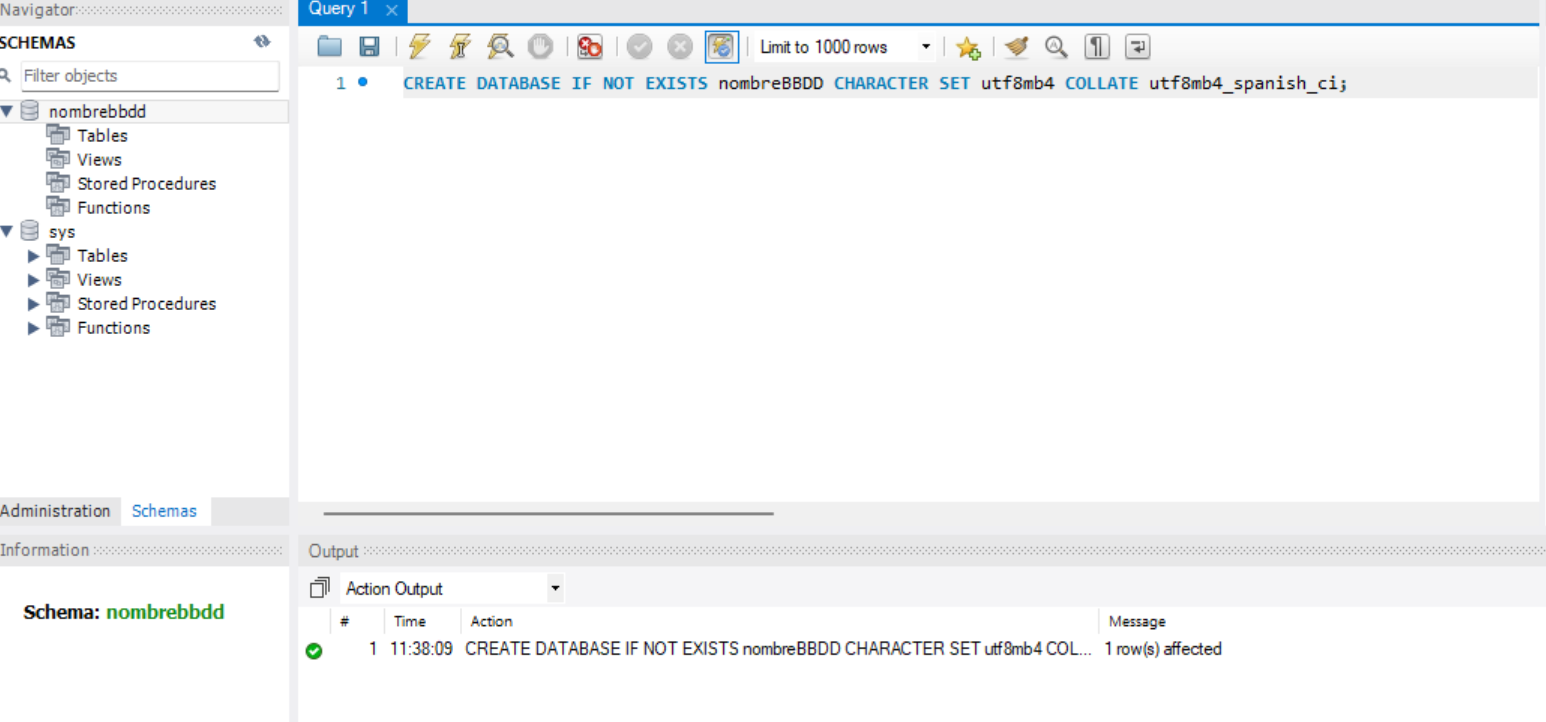

## 3.0 Seleccionar la BBDD para realizar las consultas

Una vez creada la BBDD es necesario decirle al programa **sobre que BBDD vamos a trabajar**, para ello utilizaremos la sentencia `USE`

`USE nombreBBDD`

Con esto el script permitira ejecutar todas las consultas siguientes en la BBDD

## 4.0 Crear Entidades

Antes de ponernos a crear, debemos pensar **QUE ENTIDADES TIENEN O NO RELACIONES**

- **1º SE CREAN PRIMERO AQUELLAS QUE NO DISPONEN DE RELACIONES**
- **2º SE CREAN LAS QUE SE RELACIONAN CON 1 ENTIDAD**
- **3º SE CREAN LAS QUE SIRVEN PARA RELACIONAR VARIAS ENTIDADES**

Se crean mediante el uso de la sentencia `CREATE`

`CREATE TABLE nombreEntidades`

Pero asi no estaria bien creada, **FALTA INFORMACION, POR TANTO HABRA QUE INCLUIR ESTA INFORMACION EN ESTE ORDEN**

- 1º Siempre la sentencia `IF NOT EXISTS nombreBBDD` para **evitar duplicidades y evitar errores**

> **Para poner nombre de las entidades: PONER SIEMPRE EN MINUSCULAS Y EN PLURAL**

- 2º Habra que incluir la informacion **de los atributos en el grafo relacional siguiendo estas reglas**

  * El nombre sera en minusculas y los espacios con _ : `nombre_bbdd`
  * Tipo de dato: `INT` , `TEXT`, `VARCHAR`
  * Restricciones: `NOT NULL`, `UNIQUE`,...
  * Clausulas especiales: `AUTO_INCREMENT`
  * **Dar valor a claves ajenas sin valor**: `DEFAULT` - VALOR NUMERICO

- 3º Habra que **incluir las claves PRIMARIAS Y AJENAS:**

  * Para indicar la primaria: `PRIMARY KEY (atributo id PK)`
  * Para indicar las ajenas hay que hacer 4 pasos:
     * * El primero es **generar un alias de clave foranea:** `CONSTRAINT fk_atributo id`
     * * El segundo es **definir la clave foranea**: `FOREIGN KEY (atributo id FK) REFERENCES nombre de la entidad (atributo id FK)`
     * * El tercero es **definir que sucede si se elimina la clave**: `ON DELETE` + `NO ACTION` / `CASCADE` / `SET DEFAULT` / `SET NULL`
     * * El cuarto es **definir que sucede si se actualiza la clave**: `ON UPDATE` + `NO ACTION` / `CASCADE` / `SET DEFAULT` / `SET NULL`

    > LAS ACCIONES CONCRETAS PUEDEN SER:
    > > `NO ACTION` **PARA NO GENERAR CAMBIOS**
    > >
    > > `CASCADE` **PARA ACTUALIZAR AL CAMBIO**
    > >
    > > `SET DEFAULT` **PARA PONER VALOR POR DEFECTO**  PERO SOLO SE PODRA HACER SI HEMOS DEFINIDO PREVIAMENTE UN VALOR POR DEFECTO
    > >
    > > `SET NULL` **PARA PONER VALOR NULL** SI LO PERMITE EL CAMPO


- 4º **OPCIONAL** Indicar el motor de almacenaje mediante `ENGINE` y podemos indicar ***InnoDB***

> **Es muy recomendable porque asi controlamos sobre que motor de almacenamiento se ha utilizado para guardar la informacion**



In [ ]:
CREATE TABLE IF NOT EXISTS autores (
                                	id_autor INT NOT NULL AUTO_INCREMENT,
                                    nombre VARCHAR (50) NOT NULL,
                                    apellidos VARCHAR (100) NOT NULL,
                                    fnac DATE,
                                    PRIMARY KEY (id_autor)
                                    ) ENGINE InnoDB;

CREATE TABLE IF NOT EXISTS clientes(
                                	id_cliente INT NOT NULL AUTO_INCREMENT,
                                    nombre VARCHAR (50) NOT NULL,
                                    apellido1 VARCHAR (100) NOT NULL,
                                    apellido2 VARCHAR (100) NOT NULL,
                                    fnac DATE NOT NULL,
                                    email VARCHAR (100) NOT NULL UNIQUE,
                                    PRIMARY KEY (id_cliente)
                                    ) ENGINE InnoDB;
CREATE TABLE IF NOT EXISTS libros(
                                	id_libro INT NOT NULL AUTO_INCREMENT,
                                    titulo VARCHAR (100) NOT NULL UNIQUE,
                                    id_autor INT NOT NULL,
                                    PRIMARY KEY (id_libro),
                                    CONSTRAINT fk_autores
										FOREIGN KEY (id_autor) REFERENCES autores (id_autor)
										ON DELETE NO ACTION
                                        ON UPDATE CASCADE
                                    ) ENGINE InnoDB;
CREATE TABLE IF NOT EXISTS reservas (
                                	id_reserva INT NOT NULL AUTO_INCREMENT,
                                    freserva DATE NOT NULL, 
                                    id_libro INT NOT NULL,
                                    id_cliente INT NOT NULL,
                                    PRIMARY KEY (id_reserva),
                                    CONSTRAINT fk_libros
										FOREIGN KEY (id_libro) REFERENCES libros (id_libro)
                                        ON DELETE NO ACTION
                                        ON UPDATE CASCADE,
                                    CONSTRAINT fk_clientes    
										FOREIGN KEY (id_cliente) REFERENCES clientes (id_cliente)
										ON DELETE NO ACTION
                                        ON UPDATE CASCADE
                                    ) ENGINE InnoDB;

## 5.0 Modificando Estructuras de la Bases de datos: entidades y atributos

Una vez visto como se crean BBDD, con sus entidades, atributos y claves, lo siguiente es **conocer como podemos manejarlas y alterarlas** mediante consultas DDL.

#### `ALTER` para alterar estructuras

Utilizaremos el comando `ALTER` para modificar estructuras de la BBDD, se expresa asi:

* 1º Indicamos la consulta para **activar la alteracion** `ALTER` + `TABLE`/`DATABASE`/... + nombre

> EJ: `ALTER TABLE autores`

* 2º Indicamos la **modificacion**:

- `RENAME TO` / `CHANGE` **PARA CAMBIAR EL NOMBRE**, hay variantes:

> `RENAME COLUMN` + nombre atributo `TO` + nombre nuevo atributo **cambia el nombre DE UN ATRIBUTO**
>
> `RENAME TABLE` + nombre tabla `TO` + nombre nuevo tabla **cambia el nombdre DE UNA TABLA**

- `ADD` **PARA AÑADIR ELEMENTOS A LA ESTRUCTURA**, hay variantes

> `ADD COLUMN` + nombre atributo + tipo de dato +  restricciones + clausulas;  **añade UN ATRIBUTO**
>
> `ADD  CONSTRAINT` +  pk_nombreAtributo +  `PRIMARY KEY` (pk_nombreAtributo); **añade UNA CLAVE PRIMARIA**
>
> `ADD  CONSTRAINT` +  fk_nombreAtributo +  `FOREIGN KEY` (fk_nombreAtributo) + `REFERENCES` + nombre tabla +  (id_nombreAtributo) + ACCIONES CONCRETAS ; **añade UNA CLAVE FORANEA**

- `MODIFY` **PARA MODIFICAR UN ELEMENTO**, hay variantes:

> `MODIFY COLUMN`+ nombre atributo + Tipo de dato + restricciones + clausulas **modifica UN ATRIBUTO**
>
> ES MUY IMPORTANTE TENER EN CUENTA QUE SEGUN QUE CAMBIES, **PUEDE PROVOCAR ERRORES SI YA EXISTEN DATOS**

- `DROP` **PARA ELIMINAR UN ELEMENTO**, hay variaciones

> `DROP COLUMN` + nombre atriburo **para eliminar UN ATRIBUTO**
>
> `ADD  CONSTRAINT` +  fk_nombreAtributo **elimina UNA RESTRICCION DE UN ATRIBUTO**



## 6.0 Modificacion de Datos: Consultas de Insercion, modificacion y eliminacion de datos.

Este tipo de consultas son DML, es decir, **consultas de manipulacion de datos** y no de sus estructuras.

#### `INSERT` para insertar datos

- `INSERT INTO` + nombreTabla(nombreAtributo1, nombreAtributo2,...) + `VALUES` + (Valor1, valor2,...);

 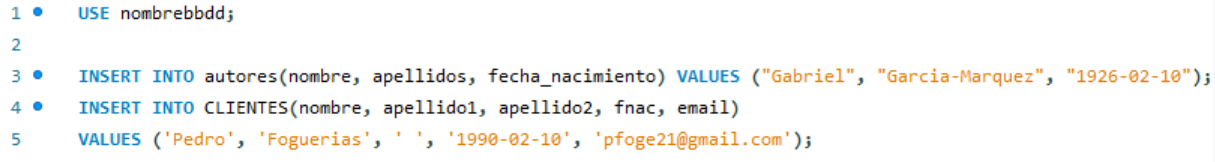

Hay que tener en cuenta:

> 1. Hay que tener en cuenta que **el orden de los atributos es el que se va a marcar para asignar valores**
>
> 2. El formato fecha es **YYYY-MM-DD** pero se puede utilizar una funcion **para cambiar el formato fecha**
>
>> `STR_TO_DATE` + ("fecha con formato original" , "%d/%m/%Y")
>

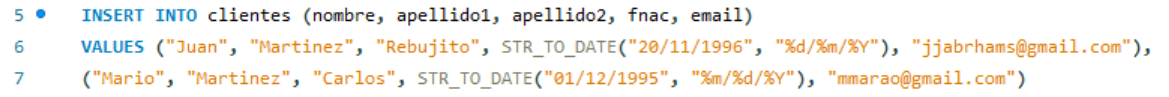

>
> 3. **NO PODREMOS DEJAR CAMPOS `NOT NULL` VACIOS**
>
> 4. Hay que tener muy en cuenta las restricciones ya que dara error de no cumplirlas
>
> 5. Si escribes varios `INSERT INTO` seguidos **RECUERDA PONER EL ;**
>
> 6. **SE PUEDEN CONCATENAR CONSULTAS DE INSERCION INDICANDO MAS VALORES CON ()**


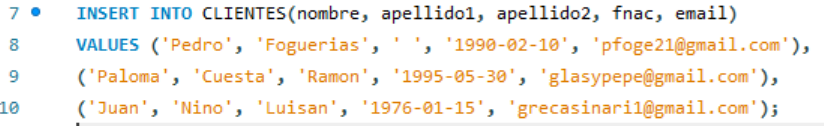

> 7. Al generar un error de insercion, **el ID se salta puede introducir datos con ID's saltados**

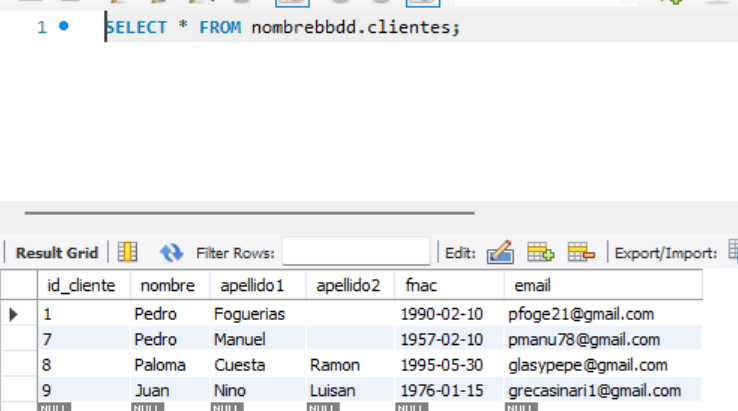

> 8. Si quieres insertar un campo FK, **DEBERAS INDICAR EL ID CONCRETO BUSCANDOLO EN LA TABLA**




#### `DELETE FROM` para eliminar datos

- `DELETE FROM` + nombreTabla + `WHERE` + nombreAtributo + condicion (= valor, > valor,...); **BORRARA UNOS DATOS CONCRETOS**

- `DELETE FROM` + nombreTabla; **BORRARA TODOS LOS DATOS**


#### `UPDATE` para actualizar datos existentes

- `UPDATE` + nombreTabla + `SET` + nombreAtributo = valor + `WHERE` + nombreAtributo + condicion (= valor, > valor,...) ;

Hay que tener en cuenta:

> 1. **Si quieres generar un cambio para muchos registros TE SALTARA UN AVISO PARA HACERLO SALTANDOTE EL MODO SEGURO**
>
> Sera necesario realizar esta sentencia para descativarlo y activarlo

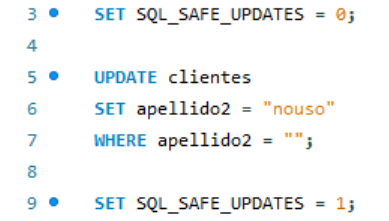

## 7.0 Consultas y Filtrados de Datos 

Estas consultas nos van a permitir visualizar datos de nuestras entidades **DEL MODO QUE QUERAMOS QUE SE MUESTREN**

#### `SELECT` para seleccionar datos

- Se puede utilizar unicamente `SELECT` + funcion **PARA SELECCIONAR UNA FUNCION**
  
> Se pueden **CONCATENAR FUNCIONES Y GENERAR UNA TABLA CON LOS RESULTADOS**

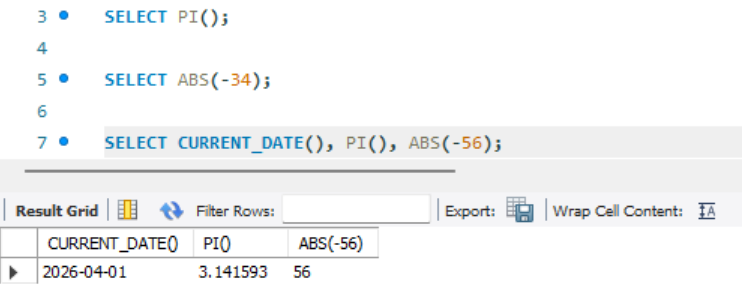

> Se pueden establecer **ALIAS PARA MEJORAR LOS RESULTADOS**

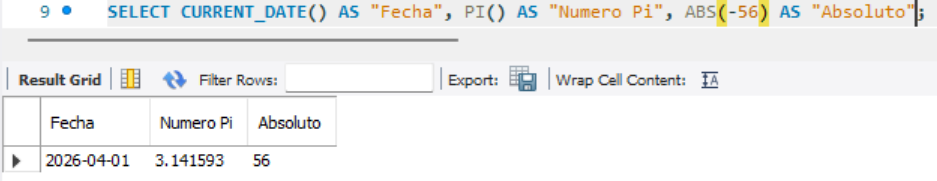

- Se pueden **SELECCIONAR ATRIBUTOS** asi: `SELECT` + nombreTabla.nombreAtributo + `FROM` + nombreTabla;

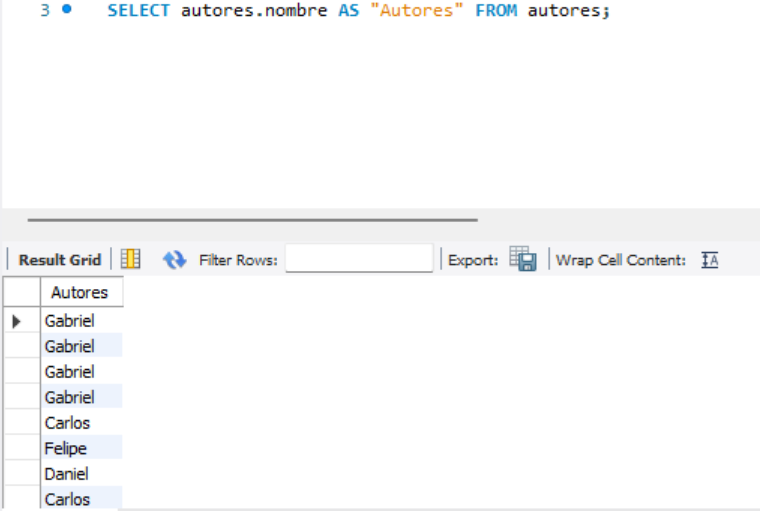

> **SI UTILIZAS EL ASTERISCO (*) SE SELECCIONAN TODOS LOS ATRIBUTOS**

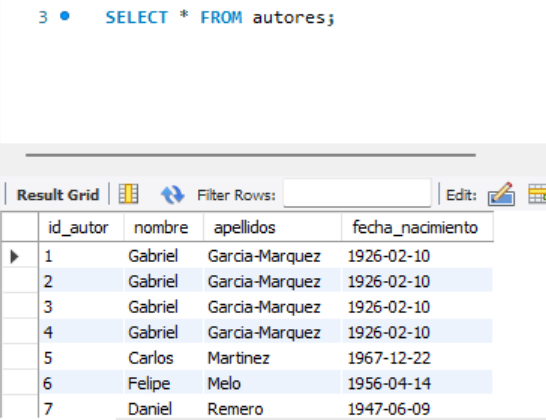

> **SI UTILIZAS EL ASTERISCO (*) + NOMBREATRIBUTO SE SELECCIONAN TODOS LOS VALORES DE ESE ATRIBUTO**

- Se pueden **CONCATENAR ATRIBUTOS** asi: `SELECT` + `CONCAT` + (nombreAtributo1, separador, nombreAtributo2,..) + `AS` + nombreConcatenacion + `FROM` + nombreTabla;

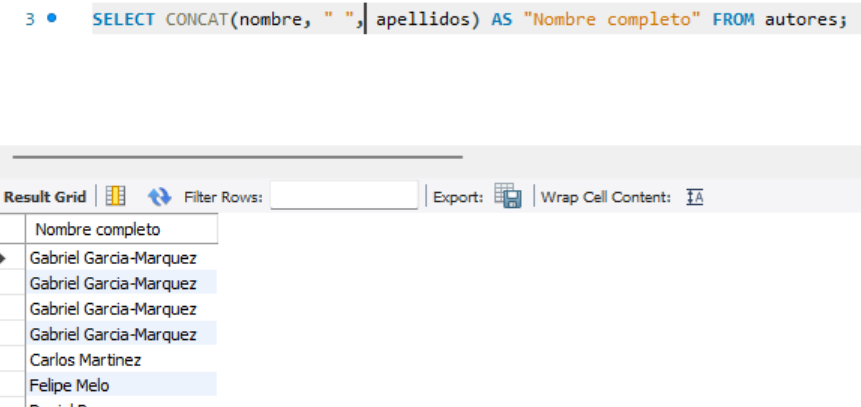

> ESTA FUNCION SE UTILIZA **SI NO TE INTERESA QUE EL SEPARADOR SEA DISTINTO Y DE MAS INFORMACION**


- **Puedes hacer uso de `CONCAT_WS` para establecer UN SEPARADOR FIJO PARA TODOS LOS ATRIBUTOS SIN TENER QUE INDICARLO SIEMPRE**

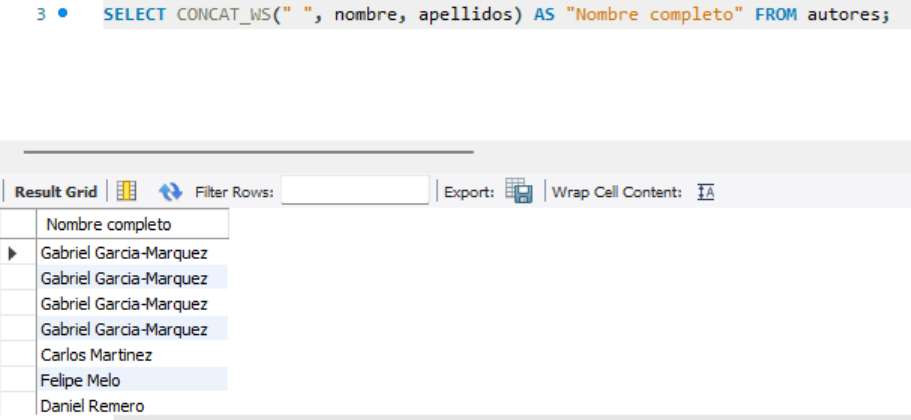

> ESTA FUNCION SE UTILIZA **SI TE INTERESA QUE EL SEPARADOR SEA IGUAL**